# Split features into train, val, test sets based on video IDs


In [2]:
import os
import json

# === Load the train, validation, and test video id ===
n_train_videos = 25985
n_val_videos   =  3000
n_test_videos  =  5808
vatex_data_dir = "/mnt/d/__VC-Transformer-KG/data/VATEX-34793"

with open(f"{vatex_data_dir}/metadata/vatex_train_english_v1.0_privacy_limited.json", "r") as f:
    train_data = json.load(f)
    train_video_ids = set([item['videoID'] for item in train_data])
    assert len(train_video_ids) == n_train_videos
with open(f"{vatex_data_dir}/metadata/vatex_val_english_v1.0_privacy_limited.json", "r") as f:
    val_data = json.load(f)
    val_video_ids = set([item['videoID'] for item in val_data])
    assert len(val_video_ids) == n_val_videos
with open(f"{vatex_data_dir}/metadata/vatex_public_test_english_v1.1_privacy_limited.json", "r") as f:
    test_data = json.load(f)
    test_video_ids = set([item['videoID'] for item in test_data])
    assert len(test_video_ids) == n_test_videos

print(f"Number of train videos: {len(train_video_ids):5d}")
print(f"Number of val videos  : {len(val_video_ids  ):5d}")
print(f"Number of test videos : {len(test_video_ids ):5d}")

Number of train videos: 25985
Number of val videos  :  3000
Number of test videos :  5808


In [3]:
import h5py
from tqdm import tqdm

# === Define the feature type and paths ===
# feature_type = "newBlip2ClsKF"
# feature_type = "newMViTv2"
# feature_type = "newImgCapBlip2KF"
for feature_type in ["newBlip2ClsKF", "newMViTv2", "newImgCapBlip2KF"]:
    print(f"========== Processing feature type: {feature_type} ==========")
    total_feature_path = f"{vatex_data_dir}/features/VATEX_{feature_type}.hdf5"
    train_feature_path = f"{vatex_data_dir}/features/VATEX_{feature_type}_train.hdf5"
    val_feature_path   = f"{vatex_data_dir}/features/VATEX_{feature_type}_val.hdf5"
    test_feature_path  = f"{vatex_data_dir}/features/VATEX_{feature_type}_test.hdf5"

    train_features = {}
    test_features = {}
    val_features = {}

    # Split the features into train, validation, and test sets
    print("Splitting features into train, validation, and test sets...")
    with h5py.File(total_feature_path, "r") as f:
        assert len(f.keys()) == (n_train_videos + n_val_videos + n_test_videos)
        for key in tqdm(f.keys(), desc="Splitting features"):
            assert len(f[key].shape) == 2
            if   key in train_video_ids: train_features[key] = f[key][:]
            elif key in val_video_ids  : val_features[key]   = f[key][:]
            elif key in test_video_ids : test_features[key]  = f[key][:]
            else: raise ValueError(f"Unexpected video ID: {key}")

    with h5py.File(train_feature_path, "w") as f:
        for key, value in train_features.items():
            f.create_dataset(key, data=value)
    with h5py.File(val_feature_path, "w") as f:
        for key, value in val_features.items():
            f.create_dataset(key, data=value)
    with h5py.File(test_feature_path, "w") as f:
        for key, value in test_features.items():
            f.create_dataset(key, data=value)

    # Verify the splits
    with h5py.File(train_feature_path, "r") as f:
        print(f"Number of training videos: {len(f.keys())}")
        assert len(f.keys()) == n_train_videos
    with h5py.File(val_feature_path, "r") as f:
        print(f"Number of validation videos: {len(f.keys())}")
        assert len(f.keys()) == n_val_videos
    with h5py.File(test_feature_path, "r") as f:
        print(f"Number of test videos: {len(f.keys())}")
        assert len(f.keys()) == n_test_videos

========== Processing feature type: newBlip2ClsKF ==========
Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 34793/34793 [00:36<00:00, 957.05it/s] 


Number of training videos: 25985
Number of validation videos: 3000
Number of test videos: 5808
========== Processing feature type: newMViTv2 ==========
Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 34793/34793 [00:34<00:00, 1000.09it/s]


Number of training videos: 25985
Number of validation videos: 3000
Number of test videos: 5808
========== Processing feature type: newImgCapBlip2KF ==========
Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 34793/34793 [00:36<00:00, 955.76it/s] 


Number of training videos: 25985
Number of validation videos: 3000
Number of test videos: 5808


# GOP Analysis

In [2]:
import pandas as pd

gop_df = pd.read_csv("./vatex_new_gop_counts.csv")
keyframe_df = pd.read_csv("./vatex_new_keyframe_counts.csv")
merged_df = pd.merge(gop_df, keyframe_df, on="video_id")
merged_df.head()

,video_id,gop_count,keyframe_count
0,qOTIoIseQtw_000001_000011,4,4
1,ITYTeU9_n2Y_000045_000055,9,9
2,oN0dnURr3Pc_000007_000017,8,8
3,1W4mXOhrXhs_000010_000020,5,5
4,Aig3sKZCSLo_000135_000145,9,9


In [3]:
(merged_df["gop_count"] == merged_df["keyframe_count"]).sum()

34793

In [4]:
merged_df.sort_values(by="gop_count", ascending=False).head(20)

,video_id,gop_count,keyframe_count
31431,-5X5a5u_qJ0_000000_000010,10,10
14245,rGn_phOp9K8_000025_000035,9,9
14232,JzRVLh06c8M_000083_000093,9,9
14233,BHVi2XIab4o_000070_000080,9,9
14234,LTK8wYoK3H8_000021_000031,9,9
32162,l8r_tFC1pm0_000000_000010,9,9
32150,_3TcyjX2WQo_000015_000025,9,9
14248,LfJbzm56XJI_000025_000035,9,9
14250,-T2V_zRoSi4_000000_000010,9,9
26731,bj_kAPISHaE_000109_000119,9,9


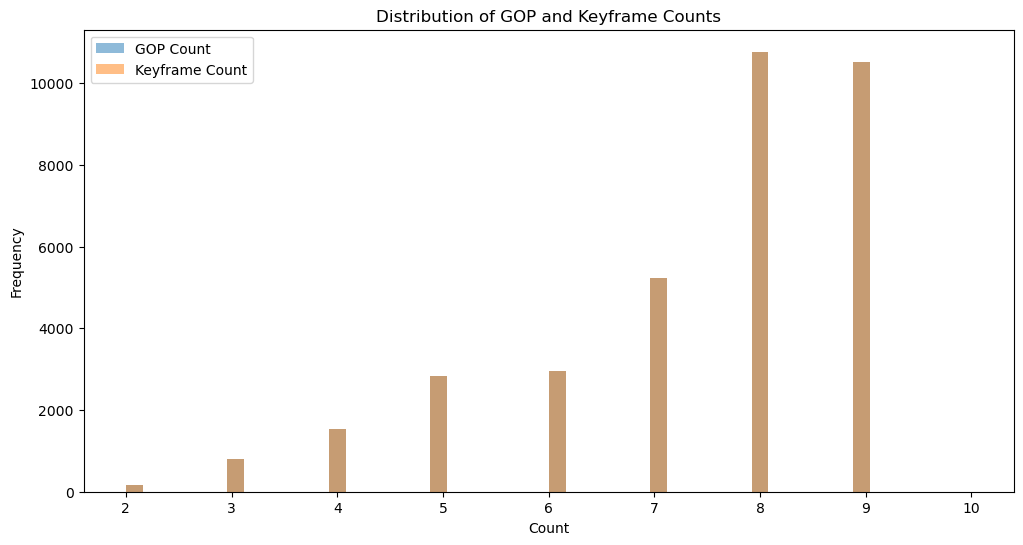

In [5]:
# Plot the distribution of GOP and keyframe counts
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(merged_df["gop_count"], bins=50, alpha=0.5, label="GOP Count")
plt.hist(merged_df["keyframe_count"], bins=50, alpha=0.5, label="Keyframe Count")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of GOP and Keyframe Counts")
plt.legend()
plt.show()

In [6]:
merged_df.describe()

,gop_count,keyframe_count
count,34793.000000,34793.000000
mean,7.418274,7.418274
std,1.624516,1.624516
min,2.000000,2.000000
25%,7.000000,7.000000
50%,8.000000,8.000000
75%,9.000000,9.000000
max,10.000000,10.000000


- GOP Analysis on Train Set:


In [7]:
import json
import pandas as pd

n_train_videos = 25985
vatex_data_dir = "/mnt/d/__VC-Transformer-KG/data/VATEX-34793"
with open(f"{vatex_data_dir}/metadata/vatex_train_english_v1.0_privacy_limited.json", "r") as f:
    train_data = json.load(f)
    train_video_ids = set([item['videoID'] for item in train_data])
    assert len(train_video_ids) == n_train_videos

gop_df = pd.read_csv("./vatex_new_gop_counts.csv")
train_df = gop_df[gop_df["video_id"].isin(train_video_ids)]
train_df.describe()

,gop_count
count,25985.000000
mean,7.414893
std,1.619283
min,2.000000
25%,7.000000
50%,8.000000
75%,9.000000
max,9.000000


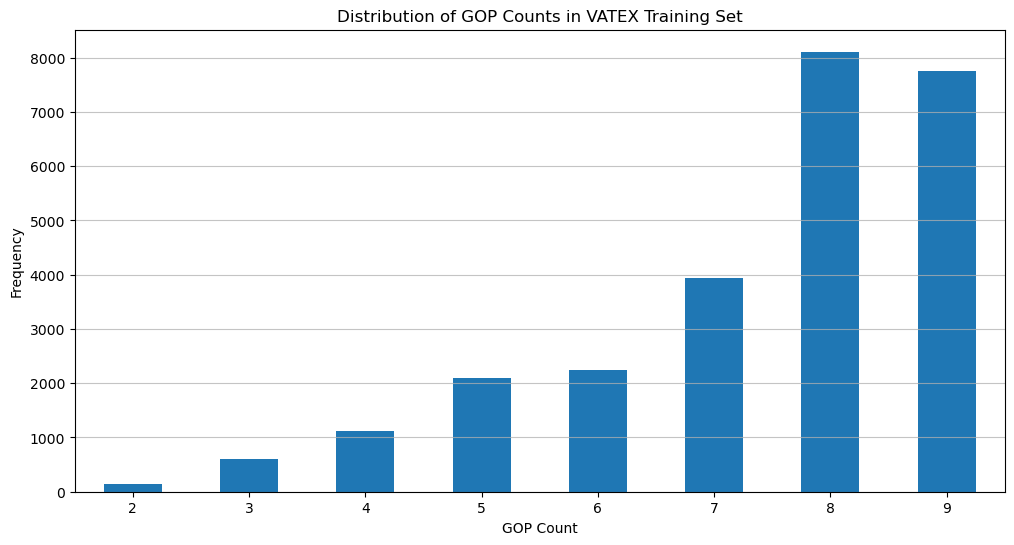

In [8]:
from matplotlib import pyplot as plt
train_df["gop_count"].value_counts().sort_index().plot(kind="bar", figsize=(12, 6))
plt.xlabel("GOP Count")
plt.ylabel("Frequency")
plt.title("Distribution of GOP Counts in VATEX Training Set")
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0)
plt.show()

In [9]:
train_df["gop_count"].quantile([0.25, 0.50, 0.75, 0.85, 0.95])

0.25    7.0
0.50    8.0
0.75    9.0
0.85    9.0
0.95    9.0
Name: gop_count, dtype: float64

# Video Duration Analysis

In [17]:
import json

with open("../data/VATEX/metadata/vatex_val_english_v1.0_privacy_limited.json", "r") as f:
    data = json.load(f)

captions = []
for item in data:
    vid = item['videoID']
    assert type(item['enCap']) == list, f"[VATEXVocab.load_captions] {vid} has {type(item['enCap'])} captions, expected list."
    assert len(item['enCap']) == 10, f"[VATEXVocab.load_captions] {vid} has {len(item['enCap'])} captions, expected 10."
    captions += item['enCap']

In [18]:
len(captions)

25640

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("./videos_240_h264_keyint_40.csv")
df.head()

,file_name,duration_seconds
0,qOTIoIseQtw_000001_000011.mp4,10.000000
1,ITYTeU9_n2Y_000045_000055.mp4,10.010000
2,oN0dnURr3Pc_000007_000017.mp4,10.000000
3,1W4mXOhrXhs_000010_000020.mp4,10.000000
4,Aig3sKZCSLo_000135_000145.mp4,10.002694


In [4]:
df.sort_values(by="duration_seconds", ascending=False).head(20)

,file_name,duration_seconds
20737,TLzXbcs9Yvc_000028_000038.mp4,10.172852
9878,Q-sORCU8iuM_000011_000021.mp4,10.166667
19409,gDdLDUBI998_000200_000210.mp4,10.166667
11101,fD5DVfsUY3Q_000026_000036.mp4,10.149573
8980,brJ2L7pbeA0_000108_000118.mp4,10.142857
16441,UmLG8pI25DI_000210_000220.mp4,10.142857
4921,8GSgaJsoJ-A_000034_000044.mp4,10.123809
1245,KI6ZZjgWrSY_000000_000010.mp4,10.122883
1664,Db4dm5z99DA_000000_000010.mp4,10.122636
2340,09dQut5GJ68_000049_000059.mp4,10.120976
